Andrew Doherty Munro
DATA 30195
Final Project Notebook

Question and Motivation

Background and Literature Review

Data Sources

Results

In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

Load in generic "Parks" shapefile, subset to Chicago and project to Illinois State Plane East CRS:

In [17]:
parks = gpd.read_file(r'data/shapefiles/Parks.shp')

chicago_parks = parks[parks['Park_Urban'].str.contains('Chicago', na=False)]
chicago_parks = chicago_parks.to_crs(epsg=26971)

Plot to get a sense of coverage:

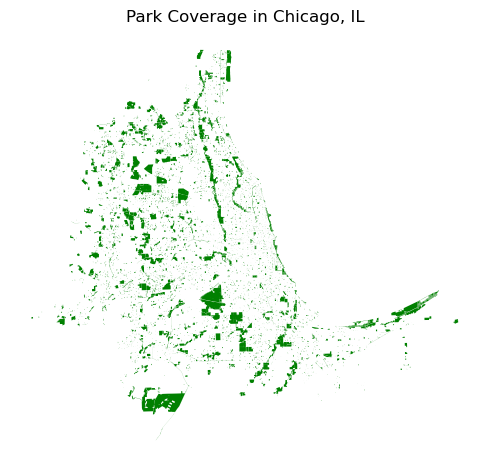

In [18]:
fig, ax = plt.subplots(1, 1)

chicago_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Park Coverage in Chicago, IL')

plt.tight_layout()
plt.show()

Land Trust also Includes a shapefile with helpful statistics attached to each park. Load this in and subset the same way as before:

In [19]:
park_stats = gpd.read_file(r'data/shapefiles/Parks_Statistics.shp')

chicago_park_stats = park_stats[park_stats['Park_Urban'].str.contains('Chicago', na=False)]
chicago_park_stats.head()

,ParkID,Park_Name,Park_Desig,Park_Local,Park_Loc_1,Park_Acces,Park_Size_,Park_Addre,Park_Urban,Park_Urb_1,...,SUM_ASIAN_,SUM_PACIFI,SUM_OTHRAC,SUM_RACE2U,SUM_HISP_S,Park_Place,Park_Pla_1,Shape_Leng,Shape_Area,geometry
34145,1700243-0001,Army Trail Nature Preserve,LCA,ADDISON PARK DISTRICT,ADDISON PARK DISTRICT,3,20.468519,270 N. Lombard Road,"Chicago, IL--IN",16264,...,67.0,0.0,2.0,12.0,220.0,Addison village,1700243,1229.660581,82833.139089,"POLYGON ((621282.398 254367.841, 621312.629 25..."
34146,1700243-0003,Farmwood Park,LP,ADDISON PARK DISTRICT,ADDISON PARK DISTRICT,3,12.024931,900 Sable Ave.,"Chicago, IL--IN",16264,...,130.0,0.0,6.0,31.0,378.0,Addison village,1700243,1692.137279,48663.151296,"MULTIPOLYGON (((621920.361 256702.411, 622103...."
34147,1700243-0004,Tamara Heights,LP,ADDISON PARK DISTRICT,ADDISON PARK DISTRICT,3,9.901588,450 Eggerding,"Chicago, IL--IN",16264,...,164.0,0.0,11.0,42.0,1479.0,Addison village,1700243,945.526064,40070.314892,"POLYGON ((622896.261 256161.648, 623184.88 256..."
34148,1700243-0005,Byron Park,LP,ADDISON PARK DISTRICT,ADDISON PARK DISTRICT,3,12.122648,100 W. Byron,"Chicago, IL--IN",16264,...,170.0,0.0,17.0,44.0,2530.0,Addison village,1700243,1062.825573,49058.695641,"MULTIPOLYGON (((623434.863 255878.389, 623807...."
34149,1700243-0006,Centennial Park,LP,ADDISON PARK DIST,ADDISON PARK DIST,3,33.901076,1776 W. Centennial Pl,"Chicago, IL--IN",16264,...,134.0,0.0,5.0,29.0,303.0,Addison village,1700243,2221.072036,137193.022140,"POLYGON ((620521.792 256049.284, 620574.791 25..."


How many parks are there in the Chicago Metro Area?

In [25]:
print('There are', len(chicago_park_stats), 'parks in the Chicago Metro Area')

There are 5658 parks in the Chicago Metro Area


There is an "Area" column, but it's not clear what the units are, so we need to investigate a bit:

In [22]:
chicago_park_stats = chicago_park_stats.to_crs('EPSG:26971')

#Illinois State Plane East uses meters for area, so take that and convert to acres:
chicago_park_stats['area_sqm'] = chicago_park_stats.geometry.area
chicago_park_stats['area_acres'] = chicago_park_stats.geometry.area * 0.000247105

chicago_park_stats[['area_sqm', 'area_acres', 'Park_Size_']].head()

,area_sqm,area_acres,Park_Size_
34145,82830.339664,20.467791,20.468519
34146,48661.588438,12.024522,12.024931
34147,40069.085688,9.901271,9.901588
34148,49057.194036,12.122278,12.122648
34149,137187.783601,33.899787,33.901076


It looks like "Park_Size_" measures acres! Now we can ask where/what the biggest parks are. There are a lot of parks (over 5,500!), so a reasonable sample is the top 1%, or 55ish parks.

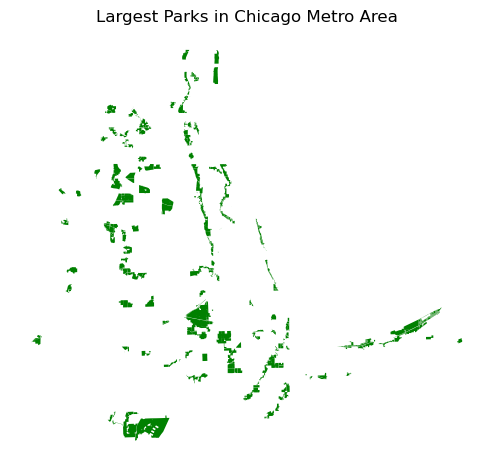

In [27]:
top_1p = np.quantile(chicago_park_stats['Park_Size_'], q=0.99)

biggest_parks = chicago_park_stats[chicago_park_stats['Park_Size_'] >= top_1p]

fig, ax = plt.subplots(1, 1)

biggest_parks.plot(color='green', ax=ax)

ax.set_axis_off()
ax.set_title('Largest Parks in Chicago Metro Area')

plt.tight_layout()
plt.show()